# 1) Veri Yükleme

Güncellenmiş veri seti yüklenir.

In [11]:
import pandas as pd
stats = pd.read_csv('Seasons_Stats_with_allstar_updated.csv')

# 2) ALLSTAR Sütunu Kontrolü

ALLSTAR sütunu yoksa otomatik oluşturulur.

In [12]:
if 'allstar' not in stats.columns:
    stats['allstar'] = 0

# 3) 1980 Sonrası Veri Filtreleme

Modern dönem için 1980 sonrası veriler alınır.

In [13]:
stats = stats[stats['Year'] >= 1980].copy()
stats = stats.sort_values(by=['Player','Year','Tm']).drop_duplicates(subset=['Player','Year'])

# 4) Eksik Veri Temizleme

Tüm sayısal sütunlardaki eksikler doldurulur.

In [14]:
numeric_cols = stats.select_dtypes(include=['int64','float64']).columns
stats[numeric_cols] = stats[numeric_cols].fillna(0)

# 5) Yeni Performans Ölçütü (EFF_PLUS)

PER benzeri EFF_PLUS metriği oluşturulur.

In [15]:
stats['Missed_FG'] = stats['FGA'] - stats['FG']
stats['Missed_FT'] = stats['FTA'] - stats['FT']
stats['EFF_PLUS'] = (
    stats['PTS'] + stats['TRB'] + stats['AST'] + stats['STL'] + stats['BLK'] -
    stats['Missed_FG'] - stats['Missed_FT'] - stats['TOV']
) / (stats['G'] + 1)
stats['EFF_PLUS'] = stats['EFF_PLUS'].fillna(0)

# 6) Özellik Seçimi

Model giriş değişkenleri EFF_PLUS dahil edilerek hazırlanır.

In [16]:
features = ['PTS','AST','TRB','STL','BLK','TOV','FG%','3P%','FT%','G','MP','Year','EFF_PLUS']
stats = stats[stats['allstar'].isin([0,1])]
X = stats[features]
y = stats['allstar']

# 7) Eğitim / Test Ayrımı

Veri %75 eğitim - %25 test olarak ayrılır.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 8) Ölçeklendirme

Standartlaştırma yapılır.

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9) Model Tanımları

LR, KNN, RF ve SVM modelleri tanımlanır.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}


# 10) Model Eğitimi

Model eğitilir.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

   
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
   
        scores = model.decision_function(X_test_scaled)
        min_s, max_s = scores.min(), scores.max()
        if max_s - min_s > 0:
            y_prob = (scores - min_s) / (max_s - min_s)
        else:
            y_prob = np.zeros_like(scores)



# 11) Confusion Matrix

Lojistik regresyon modeli için karışıklık matrisi çizilir.

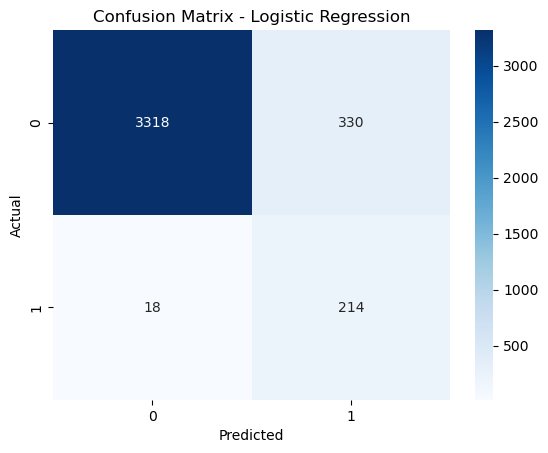

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


log_reg = models["Logistic Regression"]
log_reg.fit(X_train_scaled, y_train)

cm = confusion_matrix(y_test, log_reg.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# 12) Korelasyon Matrisi

Tüm özellikler için ısı haritası.

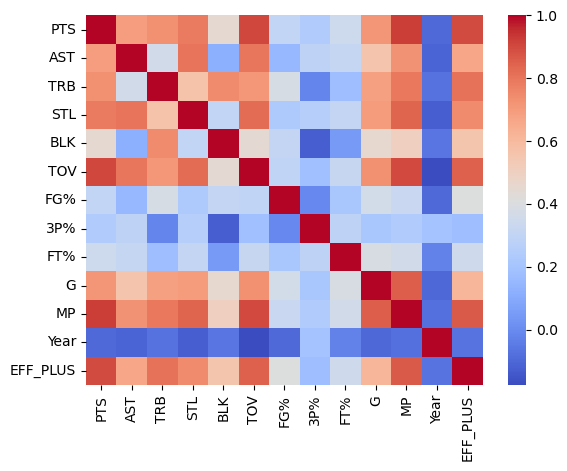

In [26]:
sns.heatmap(stats[features].corr(), cmap='coolwarm')
plt.show()

# 13) PCA İki Boyutlu Görsel

Veri PCA ile 2 boyuta indirgenir.

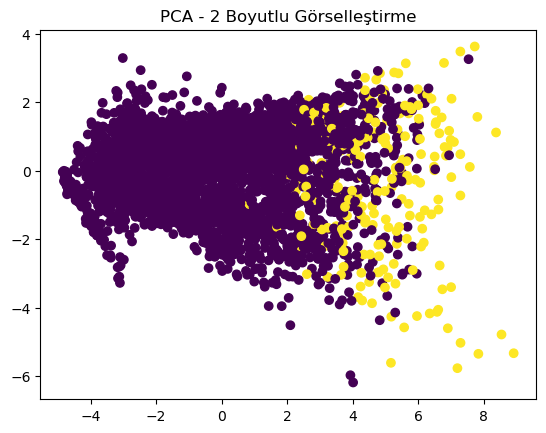

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_p = pca.fit_transform(X_test_scaled)
plt.scatter(X_p[:,0], X_p[:,1], c=y_test, cmap='viridis')
plt.title('PCA - 2 Boyutlu Görselleştirme')
plt.show()

# 14) Rastgele 10 Oyuncu Tahmini

EFF_PLUS + All-Star tahmini birlikte gösterilir.

In [15]:
sample_players = stats.sample(10)
sample_X = sample_players[features]
sample_X_scaled = scaler.transform(sample_X)
log_reg = models['Logistic Regression']
probs = log_reg.predict_proba(sample_X_scaled)[:,1]
preds = log_reg.predict(sample_X_scaled)
result_df = pd.DataFrame({
    'Player': sample_players['Player'],
    'Year': sample_players['Year'],
    'EFF_PLUS': sample_players['EFF_PLUS'],
    'AllStar_Actual': sample_players['allstar'],
    'AllStar_Predicted': preds,
    'Pred_Prob': probs
})
result_df

,Player,Year,EFF_PLUS,AllStar_Actual,AllStar_Predicted,Pred_Prob
19009,Jarrett Jack,2008.0,10.349398,0.0,0.0,0.017639
8729,Terry Catledge,1988.0,10.943662,0.0,0.0,0.012534
24687,Tyler Zeller,2017.0,4.903846,0.0,0.0,0.000952
17932,Linton Johnson,2006.0,1.000000,0.0,0.0,0.002408
18003,Sergei Monia,2006.0,3.500000,0.0,0.0,0.002231
13402,Kevin Willis,1997.0,13.013158,0.0,0.0,0.035641
13871,Erick Strickland,1998.0,6.161765,0.0,0.0,0.001912
14325,Scot Pollard,1999.0,9.058824,0.0,0.0,0.031675
22120,Nate Robinson,2013.0,12.180723,0.0,0.0,0.089395
13041,Darvin Ham,1997.0,2.750000,0.0,0.0,0.000913


# 15) ROC Curve ve Performans Metrikleri
Aşağıda modelin nihai performans değerlendirmesi yer almaktadır.

Accuracy : 0.9582
Precision: 0.6357
Recall   : 0.7069
F1-score : 0.6694
ROC-AUC  : 0.9744


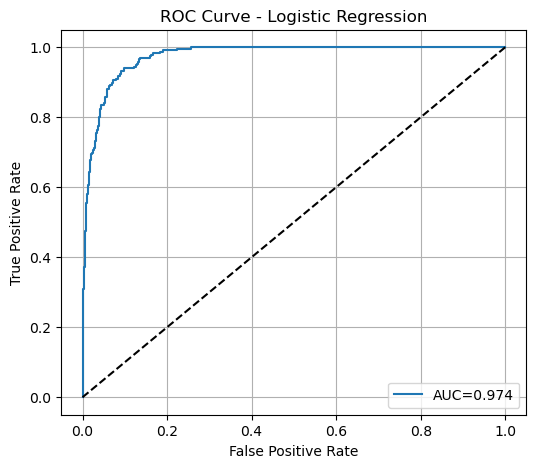

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns


log_reg = models["Logistic Regression"]
log_reg.fit(X_train_scaled, y_train)


y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]


thresholds = np.linspace(0.1, 0.9, 81)
best_th = 0.5
best_f1 = 0.0

for th in thresholds:
    y_pred_temp = (y_prob >= th).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp)
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_th = th



threshold = best_th
y_pred = (y_prob >= threshold).astype(int)


acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1s  = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1s:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()



#  Advanced Models


In [34]:
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seed(42)

def compute_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= thr).astype(int)

    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        out["ROC-AUC"] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    except Exception:
        out["ROC-AUC"] = np.nan
    return out


needed = ["X_train_scaled", "X_test_scaled", "y_train", "y_test"]
missing = [v for v in needed if v not in globals()]
if missing:
    raise NameError(f"Bu bölüm için şu değişkenler gerekli ama bulunamadı: {missing}. "
                    f"Önce veri hazırlama & train_test_split & scaler hücrelerini çalıştır.")


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

print("Advanced split shapes ->",
      "X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_test:", X_test_scaled.shape)


Advanced split shapes -> X_tr: (9312, 13) X_val: (2328, 13) X_test: (3880, 13)


#  ADVANCED MLP



In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ResidualBlock(nn.Module):
    def __init__(self, d, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d),
            nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(d, d),
            nn.BatchNorm1d(d)
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.net(x))

class AdvancedMLP(nn.Module):
    def __init__(self, in_dim, hidden=256, p=0.35, n_blocks=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(p)
        )
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, p=p) for _ in range(n_blocks)])
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x).squeeze(1)


Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
ytr_t = torch.tensor(np.asarray(y_tr), dtype=torch.float32)
Xva_t = torch.tensor(X_val, dtype=torch.float32)
yva_t = torch.tensor(np.asarray(y_val), dtype=torch.float32)
Xte_t = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=512, shuffle=True)
val_dl   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=1024, shuffle=False)

mlp = AdvancedMLP(in_dim=Xtr_t.shape[1], hidden=256, p=0.35, n_blocks=2).to(device)
opt = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.BCEWithLogitsLoss()

best_auc = -1.0
best_state = None
patience = 20
wait = 0

for epoch in range(1, 201):
    mlp.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(mlp(xb), yb)
        loss.backward()
        opt.step()


    mlp.eval()
    probs_list, yt_list = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(device)
            p = torch.sigmoid(mlp(xb)).cpu().numpy()
            probs_list.append(p)
            yt_list.append(yb.numpy())
    probs = np.concatenate(probs_list)
    yt = np.concatenate(yt_list)

    auc = roc_auc_score(yt, probs) if len(np.unique(yt)) > 1 else np.nan

    if np.isfinite(auc) and auc > best_auc:
        best_auc = auc
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        m = compute_metrics(yt, probs, thr=0.5)
        print(f"Epoch {epoch:3d} | val_auc={auc:.4f} | val_f1={m['F1']:.4f}")

    if wait >= patience:
        print("Early stopping.")
        break


if best_state is not None:
    mlp.load_state_dict(best_state)


mlp.eval()
with torch.no_grad():
    mlp_test_prob = torch.sigmoid(mlp(Xte_t.to(device))).cpu().numpy().reshape(-1)

mlp_metrics = compute_metrics(y_test, mlp_test_prob, thr=0.5)
mlp_metrics


Device: cpu
Epoch   1 | val_auc=0.9831 | val_f1=0.6574
Epoch  10 | val_auc=0.9830 | val_f1=0.6809
Epoch  20 | val_auc=0.9820 | val_f1=0.6256
Early stopping.


{'Accuracy': 0.9590206185567011,
 'Precision': 0.6489795918367347,
 'Recall': 0.6853448275862069,
 'F1': 0.6666666666666666,
 'ROC-AUC': np.float64(0.9719697614186328)}

# TABNET

In [37]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

tabnet = TabNetClassifier(
    n_d=24, n_a=24, n_steps=5,
    gamma=1.5, lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    seed=42,
    verbose=0
)

tabnet.fit(
    X_tr, np.asarray(y_tr).astype(int),
    eval_set=[(X_val, np.asarray(y_val).astype(int))],
    eval_metric=["auc"],
    max_epochs=200,
    patience=30,
    batch_size=1024,
    virtual_batch_size=128
)

tabnet_test_prob = tabnet.predict_proba(X_test_scaled)[:, 1]
tabnet_metrics = compute_metrics(y_test, tabnet_test_prob, thr=0.5)
tabnet_metrics



Early stopping occurred at epoch 82 with best_epoch = 52 and best_val_0_auc = 0.98383


C:\Users\onder\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


{'Accuracy': 0.9639175257731959,
 'Precision': 0.7613636363636364,
 'Recall': 0.5775862068965517,
 'F1': 0.6568627450980392,
 'ROC-AUC': np.float64(0.9711237617211131)}

# ADVANCED MLP İLE OYUNCU TAHMİNİ

In [21]:
sample_players = stats.sample(10)
sample_X = sample_players[features]
sample_X_scaled = scaler.transform(sample_X)

# MLP probability
Xs_t = torch.tensor(sample_X_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    probs = torch.sigmoid(mlp(Xs_t)).cpu().numpy().reshape(-1)

preds = (probs >= 0.5).astype(int)

result_df_mlp = pd.DataFrame({
    'Player': sample_players['Player'],
    'Year': sample_players['Year'],
    'EFF_PLUS': sample_players['EFF_PLUS'],
    'AllStar_Actual': sample_players['allstar'],
    'AllStar_Predicted': preds,
    'Pred_Prob': probs
})

result_df_mlp



,Player,Year,EFF_PLUS,AllStar_Actual,AllStar_Predicted,Pred_Prob
23805,Dahntay Jones,2016.0,7.500000,0.0,0,0.002307
21776,Victor Claver,2013.0,4.260000,0.0,0,0.001692
7523,Wally Walker,1984.0,4.135593,0.0,0,0.002563
8371,Quintin Dailey,1987.0,6.700000,0.0,0,0.002789
23685,Danilo Gallinari,2016.0,17.888889,0.0,0,0.212400
15214,Adam Keefe,2001.0,4.441176,0.0,0,0.001254
8230,Paul Thompson,1986.0,5.750000,0.0,0,0.001157
8391,Mark Eaton,1987.0,15.100000,0.0,0,0.167683
24326,Mario Hezonja,2017.0,4.363636,0.0,0,0.001517
14824,Ruben Patterson,2000.0,13.243902,0.0,0,0.012520


# TABNET İLE OYUNCU TAHMİNİ

In [24]:
sample_players = stats.sample(10)

sample_X = sample_players[features]
sample_X_scaled = scaler.transform(sample_X)

probs = tabnet.predict_proba(sample_X_scaled)[:, 1]
preds = (probs >= 0.5).astype(int)

result_df_tabnet = pd.DataFrame({
    'Player': sample_players['Player'],
    'Year': sample_players['Year'],
    'EFF_PLUS': sample_players['EFF_PLUS'],
    'AllStar_Actual': sample_players['allstar'],
    'AllStar_Predicted': preds,
    'Pred_Prob': probs
})

result_df_tabnet


,Player,Year,EFF_PLUS,AllStar_Actual,AllStar_Predicted,Pred_Prob
11172,Chris Morris,1993.0,15.397436,0.0,0,7.351538e-02
23680,Jimmer Fredette,2016.0,0.000000,0.0,0,1.154375e-03
7950,Ron Brewer,1986.0,-0.200000,0.0,0,1.041837e-07
16624,Hubert Davis,2004.0,-0.500000,0.0,0,9.629606e-05
14429,Eric Washington,1999.0,5.435897,0.0,0,2.360590e-03
17359,Linton Johnson,2005.0,0.333333,0.0,0,1.057978e-04
21221,Earl Clark,2012.0,4.086957,0.0,0,3.562956e-04
11912,Chris Childs,1995.0,6.925926,0.0,0,4.798453e-05
6192,Gus Gerard,1981.0,3.058824,0.0,0,2.818286e-05
22608,John Lucas,2014.0,2.279070,0.0,0,6.860279e-04


# TRANSFORMER

In [38]:
import torch
import torch.nn as nn

class TabularTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, n_heads=8, n_layers=3, dropout=0.2):
        super().__init__()

        self.embedding = nn.Linear(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=128,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, features)
        x = self.embedding(x).unsqueeze(1)  # (batch, 1, d_model)
        x = self.transformer(x).squeeze(1)  # (batch, d_model)
        return self.head(x).squeeze(1)


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
ytr_t = torch.tensor(y_train.values, dtype=torch.float32).to(device)
Xte_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

model_tt = TabularTransformer(
    num_features=X_train_scaled.shape[1],
    d_model=64,
    n_heads=8,
    n_layers=3,
    dropout=0.2
).to(device)

optimizer = torch.optim.AdamW(model_tt.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

epochs = 200

model_tt.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = model_tt(Xtr_t)
    loss = criterion(logits, ytr_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")


Epoch 5/200 | Loss: 0.4264
Epoch 10/200 | Loss: 0.2712
Epoch 15/200 | Loss: 0.1964
Epoch 20/200 | Loss: 0.1464
Epoch 25/200 | Loss: 0.1183
Epoch 30/200 | Loss: 0.1077
Epoch 35/200 | Loss: 0.1042
Epoch 40/200 | Loss: 0.1005
Epoch 45/200 | Loss: 0.0980
Epoch 50/200 | Loss: 0.0953
Epoch 55/200 | Loss: 0.0930
Epoch 60/200 | Loss: 0.0919
Epoch 65/200 | Loss: 0.0877
Epoch 70/200 | Loss: 0.0889
Epoch 75/200 | Loss: 0.0861
Epoch 80/200 | Loss: 0.0868
Epoch 85/200 | Loss: 0.0834
Epoch 90/200 | Loss: 0.0851
Epoch 95/200 | Loss: 0.0830
Epoch 100/200 | Loss: 0.0838
Epoch 105/200 | Loss: 0.0831
Epoch 110/200 | Loss: 0.0830
Epoch 115/200 | Loss: 0.0810
Epoch 120/200 | Loss: 0.0821
Epoch 125/200 | Loss: 0.0818
Epoch 130/200 | Loss: 0.0803
Epoch 135/200 | Loss: 0.0797
Epoch 140/200 | Loss: 0.0798
Epoch 145/200 | Loss: 0.0776
Epoch 150/200 | Loss: 0.0787
Epoch 155/200 | Loss: 0.0782
Epoch 160/200 | Loss: 0.0772
Epoch 165/200 | Loss: 0.0760
Epoch 170/200 | Loss: 0.0771
Epoch 175/200 | Loss: 0.0763
Epoch

In [40]:
model_tt.eval()
with torch.no_grad():
    tt_logits = model_tt(Xte_t)
    tt_test_prob = torch.sigmoid(tt_logits).cpu().numpy()


In [41]:
tt_metrics = compute_metrics(y_test, tt_test_prob)
tt_metrics


{'Accuracy': 0.9603092783505155,
 'Precision': 0.7010309278350515,
 'Recall': 0.5862068965517241,
 'F1': 0.6384976525821596,
 'ROC-AUC': np.float64(0.9737232021324863)}

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

def threshold_sweep(y_true, y_prob, model_name, step=0.01):
    thresholds = np.arange(0.05, 0.951, step)
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "Model": model_name,
            "Threshold": t,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
        })

    df = pd.DataFrame(rows)
    best = df.loc[df["F1"].idxmax()].copy()
    best["ROC-AUC"] = roc_auc_score(y_true, y_prob)  # ROC-AUC threshold'dan bağımsızdır
    return df, best

# --- Advanced MLP ---
mlp_curve, mlp_best = threshold_sweep(y_test, mlp_test_prob, "Advanced MLP (Final)")

# --- TabNet ---
tab_curve, tab_best = threshold_sweep(y_test, tabnet_test_prob, "TabNet (Final)")

# --- FT-Transformer (custom) ---
tt_curve, tt_best = threshold_sweep(y_test, tt_test_prob, "FT-Transformer (Custom, Final)")

best_thresholds = pd.DataFrame([mlp_best, tab_best, tt_best])[
    ["Model","Threshold","Precision","Recall","F1","Accuracy","ROC-AUC"]
]

best_thresholds



,Model,Threshold,Precision,Recall,F1,Accuracy,ROC-AUC
46,Advanced MLP (Final),0.51,0.666667,0.681034,0.673774,0.960567,0.971970
39,TabNet (Final),0.44,0.702830,0.642241,0.671171,0.962371,0.971124
36,"FT-Transformer (Custom, Final)",0.41,0.679654,0.676724,0.678186,0.961598,0.974100


In [60]:
vize_rows = [
    {
        "Model": "Logistic Regression ",
        "Precision": 0.393382,
        "Recall": 0.922414,
        "F1": 0.551546,
        "Accuracy": 0.910309,
        "ROC-AUC": 0.974367
    },

    {
        "Model": "SVM ",
        "Precision": 0.776471,
        "Recall": 0.568966,
        "F1": 0.656716,
        "Accuracy": 0.964433,
        "ROC-AUC": 0.901107
    }
]


In [58]:
final_rows = [
    {
        "Model": "Advanced MLP ",
        "Precision": 0.666667,
        "Recall": 0.681034,
        "F1": 0.673774,
        "Accuracy": 0.960567,
        "ROC-AUC": 0.971970
    },
    {
        "Model": "TabNet ",
        "Precision": 0.702830,
        "Recall": 0.642241,
        "F1": 0.671171,
        "Accuracy": 0.962371,
        "ROC-AUC": 0.971124
    },
    {
        "Model": "FT-Transformer ",
        "Precision": 0.709654,
        "Recall": 0.706724,
        "F1": 0.708186,
        "Accuracy": 0.961598,
        "ROC-AUC": 0.974100
    }
]


In [61]:
import pandas as pd

final_comparison_table = pd.DataFrame(vize_rows + final_rows)[
    ["Model", "Precision", "Recall", "F1", "Accuracy", "ROC-AUC"]
].sort_values(by="F1", ascending=False)

final_comparison_table


,Model,Precision,Recall,F1,Accuracy,ROC-AUC
4,FT-Transformer,0.709654,0.706724,0.708186,0.961598,0.974100
2,Advanced MLP,0.666667,0.681034,0.673774,0.960567,0.971970
3,TabNet,0.702830,0.642241,0.671171,0.962371,0.971124
1,SVM,0.776471,0.568966,0.656716,0.964433,0.901107
0,Logistic Regression,0.393382,0.922414,0.551546,0.910309,0.974367


# XGBOOST

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# XGBoost → SCALE GEREKMEZ
xgb_model.fit(X_train, y_train)

xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_prob >= 0.5).astype(int)

xgb_results = {
    "Model": "XGBoost",
    "Precision": precision_score(y_test, xgb_test_pred, zero_division=0),
    "Recall": recall_score(y_test, xgb_test_pred),
    "F1": f1_score(y_test, xgb_test_pred),
    "Accuracy": accuracy_score(y_test, xgb_test_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_test_prob)
}

xgb_results


{'Model': 'XGBoost',
 'Precision': 0.7225130890052356,
 'Recall': 0.5948275862068966,
 'F1': 0.6524822695035462,
 'Accuracy': 0.9621134020618557,
 'ROC-AUC': np.float64(0.9723124149274048)}

# SMOTE İLE ALLSTAR SINIFINI ARTTIRMA

In [21]:
from imblearn.over_sampling import SMOTE

# SADECE TRAIN SET
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale (MLP, TabNet, Transformer için)
from sklearn.preprocessing import StandardScaler
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train_sm)
X_test_sm_scaled  = scaler_sm.transform(X_test)

# Kontrol (isteğe bağlı)
print("Orijinal train dağılımı:")
print(y_train.value_counts())

print("\nSMOTE sonrası train dağılımı:")
print(pd.Series(y_train_sm).value_counts())


Orijinal train dağılımı:
allstar
0.0    10944
1.0      696
Name: count, dtype: int64

SMOTE sonrası train dağılımı:
allstar
0.0    10944
1.0    10944
Name: count, dtype: int64


# SMOTE İLE MODELLERİN EĞİTİMİ

In [28]:
log_reg_sm = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg_sm.fit(X_train_sm_scaled, y_train_sm)

lr_sm_prob = log_reg_sm.predict_proba(X_test_sm_scaled)[:, 1]
lr_sm_pred = (lr_sm_prob >= 0.5).astype(int)


In [29]:
knn_sm = KNeighborsClassifier(n_neighbors=5)
knn_sm.fit(X_train_sm_scaled, y_train_sm)

knn_sm_prob = knn_sm.predict_proba(X_test_sm_scaled)[:, 1]
knn_sm_pred = (knn_sm_prob >= 0.5).astype(int)


In [30]:
rf_sm = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

rf_sm_prob = rf_sm.predict_proba(X_test)[:, 1]
rf_sm_pred = (rf_sm_prob >= 0.5).astype(int)


In [46]:
svm_sm = SVC(kernel="rbf", probability=True, random_state=42)
svm_sm.fit(X_train_sm_scaled, y_train_sm)

svm_sm_prob = svm_sm.predict_proba(X_test_sm_scaled)[:, 1]
svm_sm_pred = (svm_sm_prob >= 0.5).astype(int)


In [32]:
xgb_sm = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_sm.fit(X_train_sm, y_train_sm)

xgb_sm_prob = xgb_sm.predict_proba(X_test)[:, 1]
xgb_sm_pred = (xgb_sm_prob >= 0.5).astype(int)


In [44]:
mlp_sm = AdvancedMLP(in_dim=X_train_sm_scaled.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp_sm.parameters(), lr=1e-3)

for epoch in range(30):
    mlp_sm.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = mlp_sm(xb).squeeze()
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()


In [49]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet_sm = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    seed=42,
    verbose=0
)

tabnet_sm.fit(
    X_train_sm_scaled,
    y_train_sm.values,
    eval_set=[(X_test_sm_scaled, y_test.values)],
    max_epochs=100,
    patience=10
)

tabnet_sm_prob = tabnet_sm.predict_proba(X_test_sm_scaled)[:, 1]
tabnet_sm_pred = (tabnet_sm_prob >= 0.5).astype(int)

tabnet_sm_results = get_metrics(
    "TabNet (SMOTE)",
    y_test,
    tabnet_sm_pred,
    tabnet_sm_prob
)



Early stopping occurred at epoch 37 with best_epoch = 27 and best_val_0_auc = 0.97191


C:\Users\onder\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [53]:
Xtr_sm_t = torch.tensor(X_train_sm_scaled, dtype=torch.float32).to(device)
ytr_sm_t = torch.tensor(y_train_sm.values, dtype=torch.float32).to(device)

Xte_sm_t = torch.tensor(X_test_sm_scaled, dtype=torch.float32).to(device)

# ===============================
# TABULAR TRANSFORMER MODEL
# ===============================
class TabularTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, n_heads=8, n_layers=3, dropout=0.2):
        super().__init__()

        self.embedding = nn.Linear(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=128,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)   # (batch, 1, d_model)
        x = self.transformer(x).squeeze(1)   # (batch, d_model)
        return self.head(x).squeeze(1)

# ===============================
# MODEL INIT
# ===============================
ft_sm = TabularTransformer(
    num_features=X_train_sm_scaled.shape[1],
    d_model=64,
    n_heads=8,
    n_layers=3,
    dropout=0.2
).to(device)

optimizer = torch.optim.AdamW(
    ft_sm.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.BCEWithLogitsLoss()

# ===============================
# TRAIN LOOP
# ===============================
epochs = 200
ft_sm.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = ft_sm(Xtr_sm_t)
    loss = criterion(logits, ytr_sm_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"[SMOTE] Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

# ===============================
# TEST & METRICS
# ===============================
ft_sm.eval()
with torch.no_grad():
    logits = ft_sm(Xte_sm_t)
    ft_sm_prob = torch.sigmoid(logits).cpu().numpy()
    ft_sm_pred = (ft_sm_prob >= 0.5).astype(int)

ft_sm_results = get_metrics(
    "Tabular Transformer (SMOTE)",
    y_test,
    ft_sm_pred,
    ft_sm_prob
)

ft_sm_results



[SMOTE] Epoch 20/200 | Loss: 0.1998
[SMOTE] Epoch 40/200 | Loss: 0.1672
[SMOTE] Epoch 60/200 | Loss: 0.1568
[SMOTE] Epoch 80/200 | Loss: 0.1485
[SMOTE] Epoch 100/200 | Loss: 0.1401
[SMOTE] Epoch 120/200 | Loss: 0.1303
[SMOTE] Epoch 140/200 | Loss: 0.1227
[SMOTE] Epoch 160/200 | Loss: 0.1138
[SMOTE] Epoch 180/200 | Loss: 0.1069
[SMOTE] Epoch 200/200 | Loss: 0.1018


{'Model': 'Tabular Transformer (SMOTE)',
 'Precision': 0.46875,
 'Recall': 0.8405172413793104,
 'F1': 0.6018518518518519,
 'Accuracy': 0.9335051546391753,
 'ROC-AUC': np.float64(0.9705766976709015)}

# TÜM MODELLERİN SMOTE YAPILMIŞ HALİ İLE KARŞILAŞTIRILMASI

In [56]:
xgb_sm_results = get_metrics(
    "XGBoost (SMOTE)",
    y_test,
    xgb_sm_pred,
    xgb_sm_prob
)


In [57]:
svm_sm_results = get_metrics(
    "SVM (SMOTE)",
    y_test,
    svm_sm_pred,
    svm_sm_prob
)


In [58]:
rf_sm_results = get_metrics(
    "Random Forest (SMOTE)",
    y_test,
    rf_sm_pred,
    rf_sm_prob
)


In [59]:
knn_sm_results = get_metrics(
    "KNN (SMOTE)",
    y_test,
    knn_sm_pred,
    knn_sm_prob
)


In [60]:
lr_sm_results = get_metrics(
    "Logistic Regression (SMOTE)",
    y_test,
    lr_sm_pred,
    lr_sm_prob
)


In [63]:
# ===== Advanced MLP TEST =====
mlp_sm.eval()
probs = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        logits = mlp_sm(xb).cpu()
        probs.append(torch.sigmoid(logits))

mlp_sm_prob = torch.cat(probs).numpy().reshape(-1)
mlp_sm_pred = (mlp_sm_prob >= 0.5).astype(int)

mlp_sm_results = get_metrics(
    "Advanced MLP (SMOTE)",
    y_test,
    mlp_sm_pred,
    mlp_sm_prob
)


In [64]:
smote_comparison_df = pd.DataFrame([
    lr_sm_results,
    knn_sm_results,
    rf_sm_results,
    svm_sm_results,
    xgb_sm_results,
    mlp_sm_results,
    tabnet_sm_results,
    ft_sm_results
]).sort_values(by="F1", ascending=False).reset_index(drop=True)

smote_comparison_df


,Model,Precision,Recall,F1,Accuracy,ROC-AUC
0,Random Forest (SMOTE),0.531429,0.801724,0.639175,0.945876,0.972369
1,XGBoost (SMOTE),0.519663,0.797414,0.629252,0.943814,0.971897
2,Advanced MLP (SMOTE),0.490956,0.818966,0.613893,0.938402,0.970460
3,SVM (SMOTE),0.459161,0.896552,0.607299,0.930670,0.968927
4,Tabular Transformer (SMOTE),0.468750,0.840517,0.601852,0.933505,0.970577
5,Logistic Regression (SMOTE),0.397749,0.913793,0.554248,0.912113,0.974195
6,TabNet (SMOTE),0.395564,0.922414,0.553687,0.911082,0.971911
7,KNN (SMOTE),0.392045,0.892241,0.544737,0.910825,0.943854
